In [3]:
from keras.preprocessing.image import load_img, array_to_img

from skimage import io
from skimage.transform import resize
import glob

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [4]:
#Function for reading in image data
def read_image_data(img_dir = "../data/archive/chest_xray/",dataset='train'):
    path_norm_images = img_dir+dataset+"/NORMAL"
    path_sick_images = img_dir+dataset+"/PNEUMONIA"

    #Load all jpeg files
    norm_files = glob.glob(f'{path_norm_images}/*jpeg')
    sick_files = glob.glob(f'{path_sick_images}/*jpeg')

    #Read images as a list of arrays
    norm_images = [io.imread(image_file, as_gray=True) for image_file in norm_files]
    sick_images = [io.imread(image_file, as_gray=True) for image_file in sick_files]

    return norm_images, sick_images



In [5]:
#read in training and test data
X_train_norm_images, X_train_sick_images = read_image_data(dataset='train')
X_test_norm_images, X_test_sick_images = read_image_data(dataset='test')

In [ ]:
#See if the images contain any useful metadata
from PIL import Image, ExifTags
img = Image.open("../data/archive/chest_xray/train/NORMAL/IM-0115-0001.jpeg")
exif = { ExifTags.TAGS[k]: v for k, v in img._getexif().items() if k in ExifTags.TAGS }

In [12]:
exif

{'ExifOffset': 26, 'ExifImageWidth': 2090, 'ExifImageHeight': 1858}

In [37]:
#We alternatively can get the image sizes from the shape of the arrays we read in
train_norm_shape = [image.shape for image in X_train_norm_images]
train_sick_shape = [image.shape for image in X_train_sick_images]
test_norm_shape = [image.shape for image in X_test_norm_images]
test_sick_shape = [image.shape for image in X_test_sick_images]

In [38]:
train_norm_height, train_norm_width = zip(*train_norm_shape)
train_sick_height, train_sick_width = zip(*train_sick_shape)
test_norm_height, test_norm_width = zip(*test_norm_shape)
test_sick_height, test_sick_width = zip(*test_sick_shape)

# Plot the width and height of images in the data set

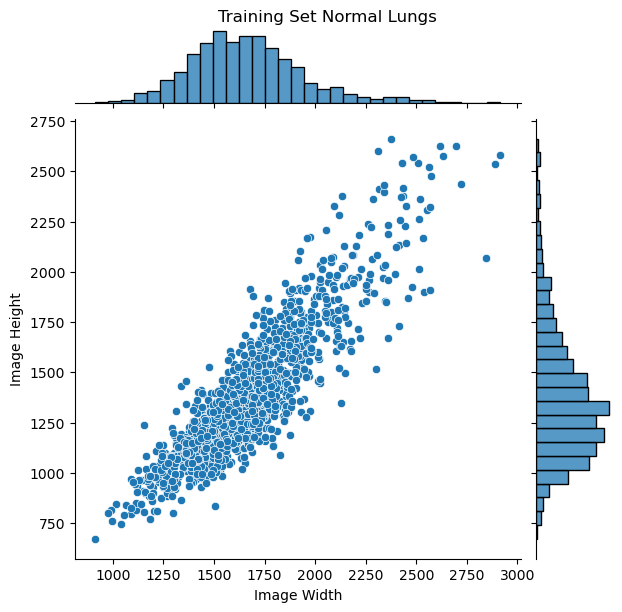

In [42]:
sns.jointplot(x=train_norm_width,y=train_norm_height)
plt.suptitle("Training Set Normal Lungs")
plt.subplots_adjust(top=0.95)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.show()

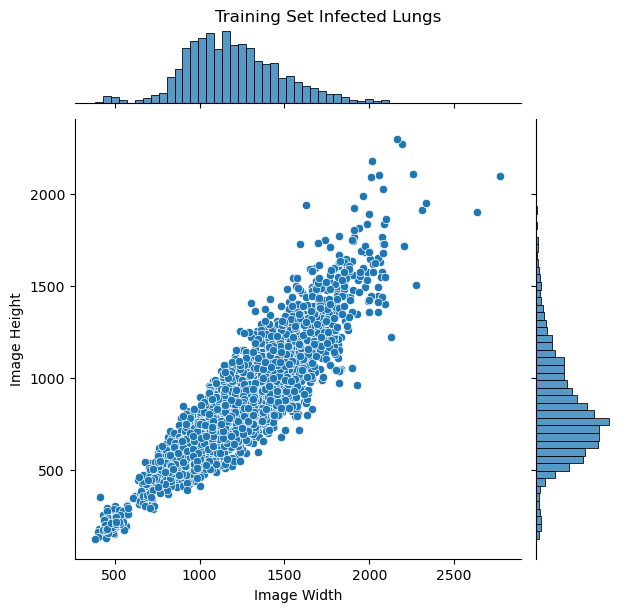

In [43]:
sns.jointplot(x=train_sick_width,y=train_sick_height)
plt.suptitle("Training Set Infected Lungs")
plt.subplots_adjust(top=0.95)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.show()

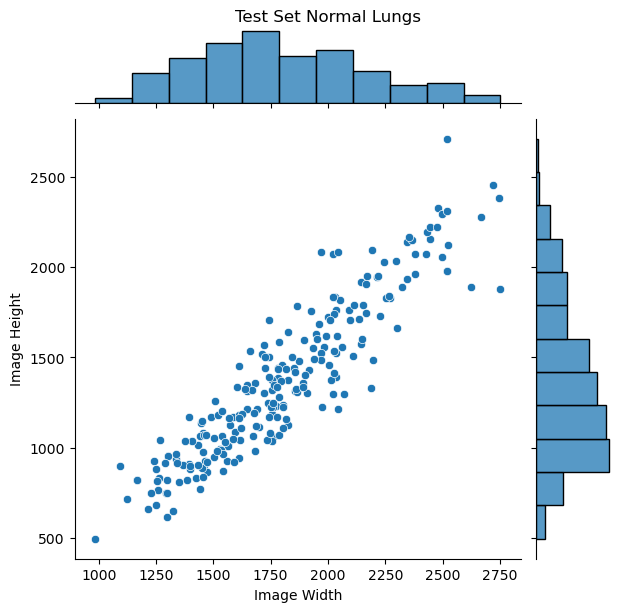

In [44]:
sns.jointplot(x=test_norm_width,y=test_norm_height)
plt.suptitle("Test Set Normal Lungs")
plt.subplots_adjust(top=0.95)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.show()

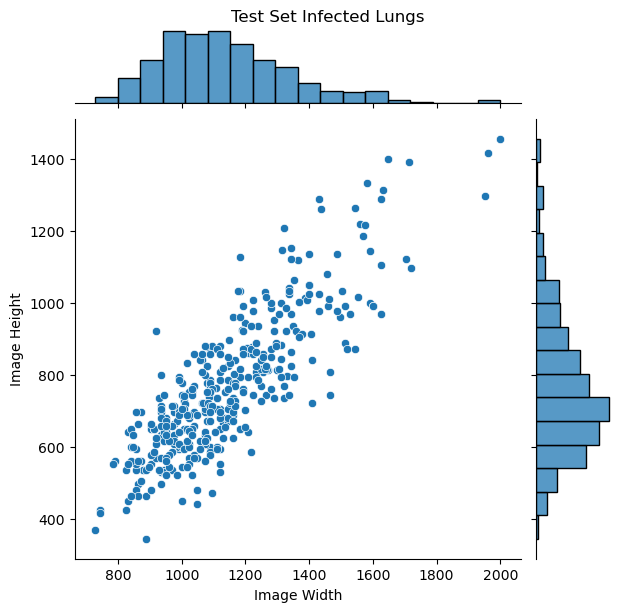

In [45]:
sns.jointplot(x=test_sick_width,y=test_sick_height)
plt.suptitle("Test Set Infected Lungs")
plt.subplots_adjust(top=0.95)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.show()

# Check The imbalance in the data set

In [50]:
n_train_norm = len(X_train_norm_images)
n_train_sick = len(X_train_sick_images)

n_test_norm = len(X_test_norm_images)
n_test_sick = len(X_test_sick_images)

In [51]:
print("The training set has {} negative labels and {} positive labels".format(n_train_norm,n_train_sick))
print("The test set has {} negative labels and {} positive labels".format(n_test_norm,n_test_sick))

The training set has 1341 negative labels and 3875 positive labels
The test set has 234 negative labels and 390 positive labels


The data set is quite imbalanced which will need to be accounted for in the modeling step

# Resize the images to the same size and visualize examples

In [52]:
def resize_images(images,image_width=128,image_height=128):
    resized = [resize(image,(image_width,image_height)) for image in images]
    
    return resized

In [53]:
#resize images
X_train_norm_resize, X_train_sick_resize, X_test_norm_resize, X_test_sick_resize = map(resize_images,[X_train_norm_images, X_train_sick_images, X_test_norm_images, X_test_sick_images])

In [54]:
# Convert to numpy arrays
X_train_norm_np, X_train_sick_np, X_test_norm_np, X_test_sick_np = map(np.array,[X_train_norm_resize, X_train_sick_resize, X_test_norm_resize, X_test_sick_resize])

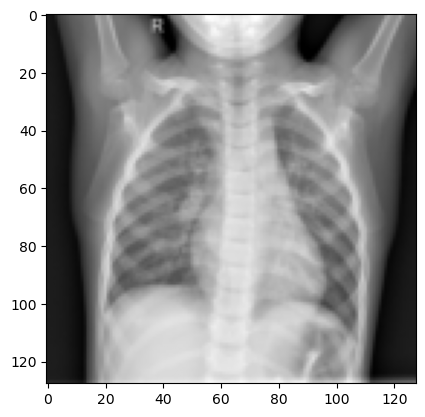

In [55]:
#Visualize 1 normal xray from the the training set
plt.imshow(X_train_norm_np[0],cmap='gray')
plt.show()

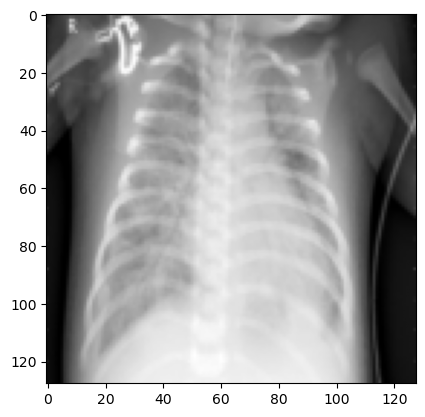

In [56]:
#Visualize 1 Pneumonia xray from the the training set
plt.imshow(X_train_sick_np[0],cmap='gray')
plt.show()

# Plot the pixel intensity distribution and compare between sick and healthy lungs

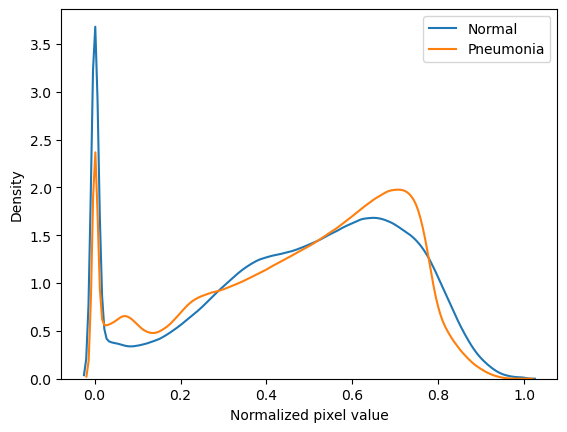

In [66]:
sns.kdeplot(X_train_norm_np.flatten(),label='Normal')
sns.kdeplot(X_train_sick_np.flatten(),label='Pneumonia')
plt.legend()
plt.xlabel("Normalized pixel value")
plt.show()

Images labeled as normal tend to have a higher amount of dark or black pixels. Images labeled as having pneumonia tend to have a higher amount of brighter pixels.

In [57]:
#Concatenate into X_train and X_test
X_train = np.concatenate( (X_train_norm_np , X_train_sick_np) )
X_test = np.concatenate( (X_test_norm_np, X_test_sick_np) )

In [58]:
#Form y_train and y_test arrays
y_train = np.concatenate( (np.zeros((len(X_train_norm_np),)) , np.ones((len(X_train_sick_np),))) )
y_test = np.concatenate( (np.zeros((len(X_test_norm_np),)) , np.ones((len(X_test_sick_np),))) )